In [1]:
import os

# 解决 Windows 下 OpenMP 重复加载导致的内核中止
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

'TRUE'

## 1. U-Net 基础知识

### 1.1 什么是 U-Net？
U-Net 是一种卷积神经网络（CNN），最早由 Olaf Ronneberger 等人在 2015 年提出，最初用于医学图像分割（如细胞边缘检测）。由于其结构简单且效果显著，现在广泛应用于各种语义分割任务（包括自动驾驶中的行人、道路分割）。

### 1.2 网络结构（“U”形结构）
U-Net 的名字来源于其网络架构图呈现出一个对称的 **“U”** 字形，主要由两部分组成：

1.  **收缩路径 (Contracting Path / Encoder)**：
    *   位于左侧。
    *   类似于经典的卷积网络（如 VGG/AlexNet）。
    *   通过连续的卷积层和池化层（Pooling），逐步提取图像的高级特征，同时降低图片的分辨率（下采样）。
    *   **作用**：捕获上下文信息（“这是什么”）。

2.  **扩张路径 (Expansive Path / Decoder)**：
    *   位于右侧。
    *   通过上采样（Up-sampling）逐步恢复图片的分辨率。
    *   **关键特性：跳跃连接 (Skip Connections)**。在每一步上采样时，将左侧对应的浅层特征图（包含了位置、边缘等细节信息）拼接到右侧的特征图中。
    *   **作用**：实现精准的定位（“它在哪里”）。

### 1.3 为什么适合行人分割？
- **像素级分类**：U-Net 输出的不是一个类标，而是与输入图像尺寸大体一致的掩膜（Mask），能精确勾勒出行人轮廓。
- **小样本学习能力强**：相比其他大型网络，U-Net 在数据量较少的情况下也能取得不错的效果。

## 2. 数据集介绍与获取

### 2.1 数据集选择：Penn-Fudan Pedestrian Dataset
为了方便演示和快速上手，本实验使用 **Penn-Fudan Database**。这是一个主要用于行人检测和分割的数据集。

- **来源**：宾夕法尼亚大学 (University of Pennsylvania)
- **内容**：包含 170 张从校园场景和城市街道采集的图片。
- **标注**：每张图片都有对应的二值掩膜（Mask），标记了行人的像素位置。
- **难度**：适中，适合作为分割任务的入门实验。

### 2.2 下载数据
我们将编写一段代码，自动检查并下载数据集到当前文件夹下的 `data/PennFudanPed` 目录。

In [2]:
import os
import requests
import zipfile
from tqdm import tqdm

def download_penn_fudan_dataset(root_dir='data'):
    # 数据集 URL
    url = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"
    dataset_path = os.path.join(root_dir, 'PennFudanPed')
    zip_path = os.path.join(root_dir, 'PennFudanPed.zip')

    if os.path.exists(dataset_path):
        print("数据集已存在，跳过下载。")
        return dataset_path

    if not os.path.exists(root_dir):
        os.makedirs(root_dir)

    # 下载
    print(f"正在下载数据集... {url}")
    response = requests.get(url, stream=True)
    total_size_in_bytes = int(response.headers.get('content-length', 0))
    block_size = 1024 # 1 Kibibyte
    progress_bar = tqdm(total=total_size_in_bytes, unit='iB', unit_scale=True)
    
    with open(zip_path, 'wb') as file:
        for data in response.iter_content(block_size):
            progress_bar.update(len(data))
            file.write(data)
    progress_bar.close()

    # 解压
    print("正在解压数据集...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(root_dir)
    
    print("数据集准备完成！")
    return dataset_path

# 执行下载
data_root = download_penn_fudan_dataset()

数据集已存在，跳过下载。


## 3. 环境准备与数据预处理

我们将定义 Dataset 类来处理图像和掩膜。掩膜图像中，背景为 0，行人可能被标记为 1, 2, ...（不同的行人实例）。为了简化为**二分类分割**（背景 vs 行人），我们将所有非 0 像素都视为 1。

In [3]:
import torch
import torch.utils.data
import torchvision.transforms as transforms
import numpy as np
from PIL import Image

class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        # 排序确保图片和掩膜一一对应
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # 加载图片和掩膜
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        
        # 将 mask 转换为 numpy 数组
        mask = np.array(mask)
        
        # 实例分割标记了每个行人不同的颜色，我们这里只做二分类（背景 vs 行人）
        # 将所有标记 ID > 0 的像素设为 1
        mask = (mask > 0).astype(np.uint8) * 255
        mask = Image.fromarray(mask, mode='L')
        
        # 先 Resize 再转为 Tensor
        img = transforms.Resize((256, 256))(img)
        mask = transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST)(mask)
        
        # 转换为 Tensor
        img_tensor = transforms.ToTensor()(img)
        img_tensor = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])(img_tensor)
        
        mask_tensor = transforms.ToTensor()(mask)

        return img_tensor, mask_tensor

    def __len__(self):
        return len(self.imgs)

# 检查数据集
dataset = PennFudanDataset(data_root)
print(f"数据集图片数量: {len(dataset)}")

数据集图片数量: 170


## 4. 构建 U-Net 模型

这里我们简化实现一个标准的 U-Net 结构。
- 4 次下采样（Encoder）
- 4 次上采样（Decoder）
- 使用 `cat` 进行通道拼接

In [4]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder (Downsampling)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(512, 1024))

        # Decoder (Upsampling)
        self.up1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(1024, 512) # 512 from up + 512 from skip
        
        self.up2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(512, 256)
        
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)
        
        self.up4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv4 = DoubleConv(128, 64)
        
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)      # 64
        x2 = self.down1(x1)   # 128
        x3 = self.down2(x2)   # 256
        x4 = self.down3(x3)   # 512
        x5 = self.down4(x4)   # 1024 (Bottom)
        
        # Decoder
        x = self.up1(x5)
        x = torch.cat([x4, x], dim=1) # Skip Connection
        x = self.conv1(x)
        
        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv2(x)
        
        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv3(x)
        
        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv4(x)
        
        logits = self.outc(x)
        return logits

# 实例化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(n_channels=3, n_classes=1).to(device)
print(f"模型已加载到: {device}")

模型已加载到: cpu


## 5. 模型训练与 Loss 分析

### 5.1 划分数据集

In [5]:
from torch.utils.data import DataLoader, random_split

# 划分数据集 80% 训练，20% 测试
full_dataset = PennFudanDataset(data_root)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

print(f"训练集大小: {len(train_dataset)}, 测试集大小: {len(test_dataset)}")

训练集大小: 136, 测试集大小: 34


### 5.2 定义损失函数与优化器
我们使用 **BCEWithLogitsLoss**，因为它结合了 Sigmoid 和二元交叉熵损失，对于二分类分割非常稳定。

In [6]:
# 定义 Dice Loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        pred_flat = pred.reshape(-1)
        target_flat = target.reshape(-1)
        
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum()
        
        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice

# 定义 IoU 准确率计算函数
def calculate_iou(pred, target, threshold=0.5):
    """计算交并比 (Intersection over Union)"""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    pred_flat = pred.reshape(-1)
    target_flat = target.reshape(-1)
    
    intersection = (pred_flat * target_flat).sum().item()
    union = (pred_flat + target_flat).sum().item() - intersection
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    return intersection / union

# 定义 Dice 准确率计算函数
def calculate_dice(pred, target, threshold=0.5):
    """计算 Dice 系数"""
    pred = (torch.sigmoid(pred) > threshold).float()
    target = target.float()
    
    pred_flat = pred.reshape(-1)
    target_flat = target.reshape(-1)
    
    intersection = (pred_flat * target_flat).sum().item()
    dice = (2.0 * intersection) / (pred_flat.sum().item() + target_flat.sum().item() + 1e-8)
    return dice

optimizer = torch.optim.RMSprop(model.parameters(), lr=1e-4, weight_decay=1e-8, momentum=0.9)
criterion = nn.BCEWithLogitsLoss()
dice_criterion = DiceLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

### 5.3 训练循环

开始训练...


Epoch 1/10: 100%|██████████| 34/34 [02:46<00:00,  4.89s/it]


Epoch 1 | Train Loss: 0.4594 | Val Loss: 0.5753 | Train IoU: 0.1660 | Val IoU: 0.0857
✓ 最优模型已保存到: models\best_unet_model.pth


Epoch 2/10: 100%|██████████| 34/34 [02:41<00:00,  4.74s/it]


Epoch 2 | Train Loss: 0.3656 | Val Loss: 0.4469 | Train IoU: 0.2026 | Val IoU: 0.1690
✓ 最优模型已保存到: models\best_unet_model.pth


...

Epoch 10/10: 100%|██████████| 34/34 [02:42<00:00,  4.79s/it]


Epoch 10 | Train Loss: 0.2107 | Val Loss: 0.2632 | Train IoU: 0.5593 | Val IoU: 0.4834
✓ 最优模型已保存到: models\best_unet_model.pth

✓ 训练完成！
✓ 训练历史已保存到: models\training_history.json


C:\Users\32077\AppData\Local\Temp\ipykernel_21200\2049966437.py:171: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_21200\2049966437.py:171: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_21200\2049966437.py:171: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_21200\2049966437.py:171: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_21200\2049966437.py:171: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\32077\AppData\Local\Temp\ipykernel_21200\2049966437.py:1

✓ 训练曲线已保存到: models/training_curves.png


d:\Anaconda\envs\iris_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\iris_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\iris_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\iris_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\iris_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missin

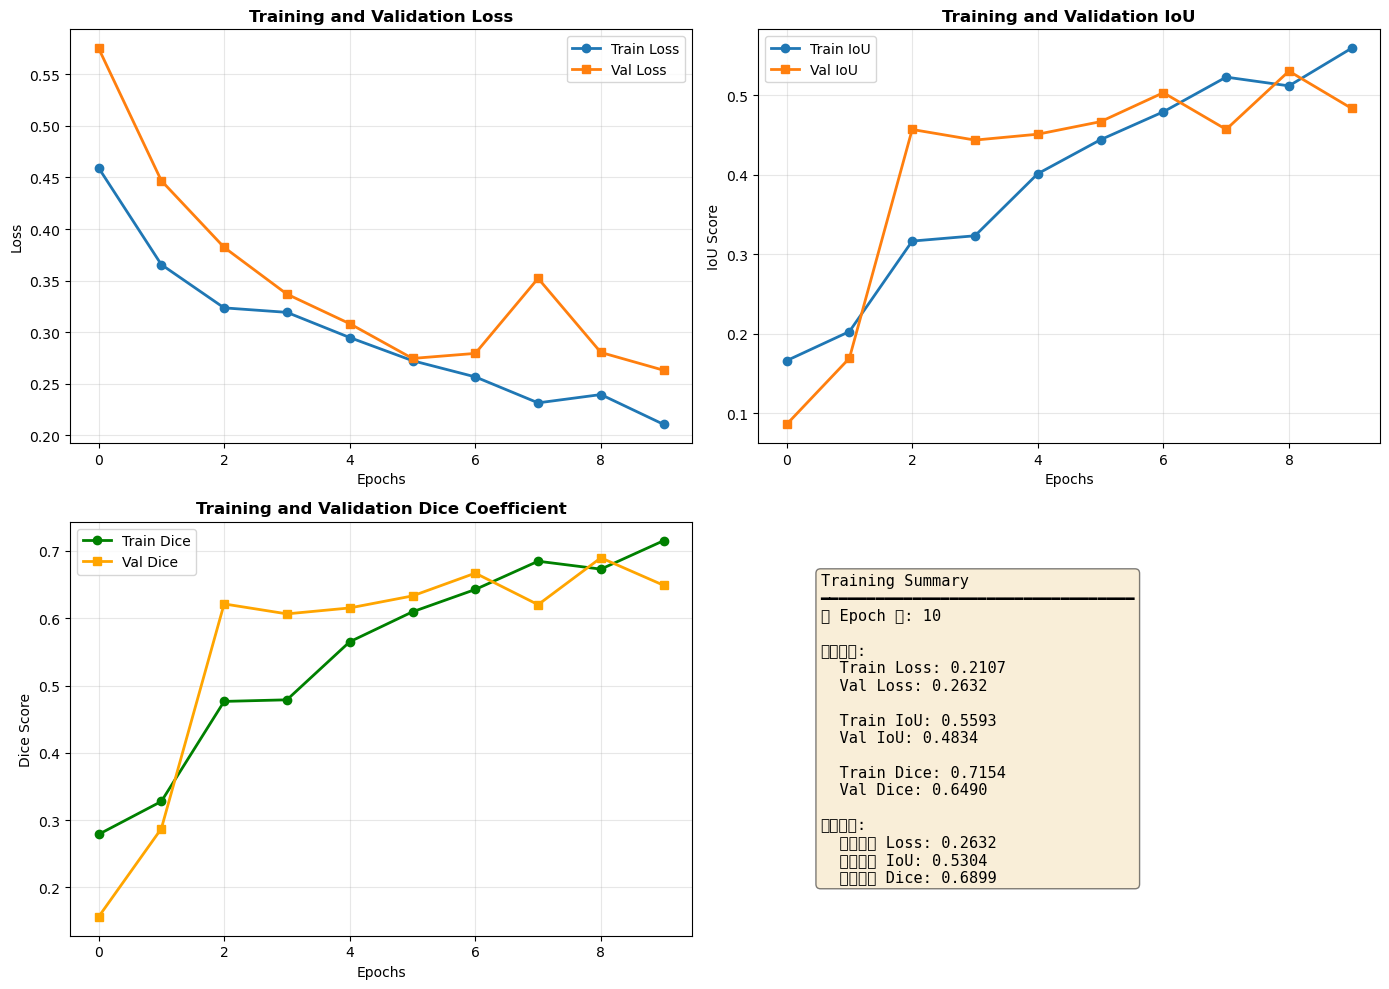

In [ ]:
import matplotlib.pyplot as plt
import json

# 配置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

epochs = 10
train_losses = []
val_losses = []
train_ious = []
val_ious = []
train_dices = []
val_dices = []

# 创建保存目录
model_save_dir = 'models'
if not os.path.exists(model_save_dir):
    os.makedirs(model_save_dir)

best_val_loss = float('inf')
best_model_path = os.path.join(model_save_dir, 'best_unet_model.pth')

print("开始训练...")

try:
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_iou = 0
        epoch_dice = 0
        batch_count = 0
        
        for imgs, true_masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            imgs = imgs.to(device)
            true_masks = true_masks.to(device)

            # 前向传播
            masks_pred = model(imgs)
            loss = criterion(masks_pred, true_masks)
            
            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 计算准确率指标
            with torch.no_grad():
                batch_iou = calculate_iou(masks_pred, true_masks)
                batch_dice = calculate_dice(masks_pred, true_masks)
                epoch_iou += batch_iou
                epoch_dice += batch_dice
            
            batch_count += 1
            
            # 清理 GPU 缓存
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        avg_train_loss = epoch_loss / len(train_loader)
        avg_train_iou = epoch_iou / batch_count
        avg_train_dice = epoch_dice / batch_count
        
        train_losses.append(avg_train_loss)
        train_ious.append(avg_train_iou)
        train_dices.append(avg_train_dice)
        
        # 验证阶段
        model.eval()
        val_loss = 0
        val_iou = 0
        val_dice = 0
        val_batch_count = 0
        
        with torch.no_grad():
            for imgs, true_masks in test_loader:
                imgs = imgs.to(device)
                true_masks = true_masks.to(device)
                masks_pred = model(imgs)
                loss = criterion(masks_pred, true_masks)
                val_loss += loss.item()
                
                val_iou += calculate_iou(masks_pred, true_masks)
                val_dice += calculate_dice(masks_pred, true_masks)
                val_batch_count += 1
                
        avg_val_loss = val_loss / len(test_loader)
        avg_val_iou = val_iou / val_batch_count
        avg_val_dice = val_dice / val_batch_count
        
        val_losses.append(avg_val_loss)
        val_ious.append(avg_val_iou)
        val_dices.append(avg_val_dice)
        
        print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train IoU: {avg_train_iou:.4f} | Val IoU: {avg_val_iou:.4f}")
        
        # 保存最优模型
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"✓ 最优模型已保存到: {best_model_path}")

    print("\n✓ 训练完成！")
    
    # 保存训练历史
    training_history = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_ious': train_ious,
        'val_ious': val_ious,
        'train_dices': train_dices,
        'val_dices': val_dices
    }
    
    history_path = os.path.join(model_save_dir, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(training_history, f, indent=4)
    print(f"✓ 训练历史已保存到: {history_path}")
    
    # 绘制 Loss 和准确率曲线
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Loss 曲线
    axes[0, 0].plot(train_losses, label='Train Loss', marker='o', linewidth=2)
    axes[0, 0].plot(val_losses, label='Val Loss', marker='s', linewidth=2)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # IoU 准确率曲线
    axes[0, 1].plot(train_ious, label='Train IoU', marker='o', linewidth=2)
    axes[0, 1].plot(val_ious, label='Val IoU', marker='s', linewidth=2)
    axes[0, 1].set_title('Training and Validation IoU', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('IoU Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Dice 系数曲线
    axes[1, 0].plot(train_dices, label='Train Dice', marker='o', linewidth=2, color='green')
    axes[1, 0].plot(val_dices, label='Val Dice', marker='s', linewidth=2, color='orange')
    axes[1, 0].set_title('Training and Validation Dice Coefficient', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Dice Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 总结统计
    axes[1, 1].axis('off')
    summary_text = f"""Training Summary
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
总 Epoch 数: {epochs}

最终结果:
  Train Loss: {train_losses[-1]:.4f}
  Val Loss: {val_losses[-1]:.4f}
  
  Train IoU: {train_ious[-1]:.4f}
  Val IoU: {val_ious[-1]:.4f}
  
  Train Dice: {train_dices[-1]:.4f}
  Val Dice: {val_dices[-1]:.4f}

最优模型:
  最低验证 Loss: {min(val_losses):.4f}
  最高验证 IoU: {max(val_ious):.4f}
  最高验证 Dice: {max(val_dices):.4f}"""
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='sans-serif', 
                    verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(os.path.join(model_save_dir, 'training_curves.png'), dpi=150, bbox_inches='tight')
    print(f"✓ 训练曲线已保存到: {model_save_dir}/training_curves.png")
    plt.show()
    
except Exception as e:
    print(f"训练出错: {str(e)}")
    import traceback
    traceback.print_exc()

## 6. 预测与结果可视化

训练完成后，我们从测试集中抽取图片，对比原始图片、真实 Mask 和预测 Mask。

In [8]:
# 加载最优模型（如果需要重新使用）
model_save_dir = 'models'
best_model_path = os.path.join(model_save_dir, 'best_unet_model.pth')

if os.path.exists(best_model_path):
    print(f"加载已保存的模型: {best_model_path}")
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("✓ 模型加载成功！")
    
    # 同时加载训练历史
    history_path = os.path.join(model_save_dir, 'training_history.json')
    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        print(f"✓ 训练历史加载成功！")
        print(f"  最低验证Loss: {min(history['val_losses']):.4f}")
        print(f"  最高验证IoU: {max(history['val_ious']):.4f}")
        print(f"  最高验证Dice: {max(history['val_dices']):.4f}")
else:
    print("未找到已保存的模型，请先运行训练步骤。")


加载已保存的模型: models\best_unet_model.pth
✓ 模型加载成功！
✓ 训练历史加载成功！
  最低验证Loss: 0.2632
  最高验证IoU: 0.5304
  最高验证Dice: 0.6899


进行预测和可视化...


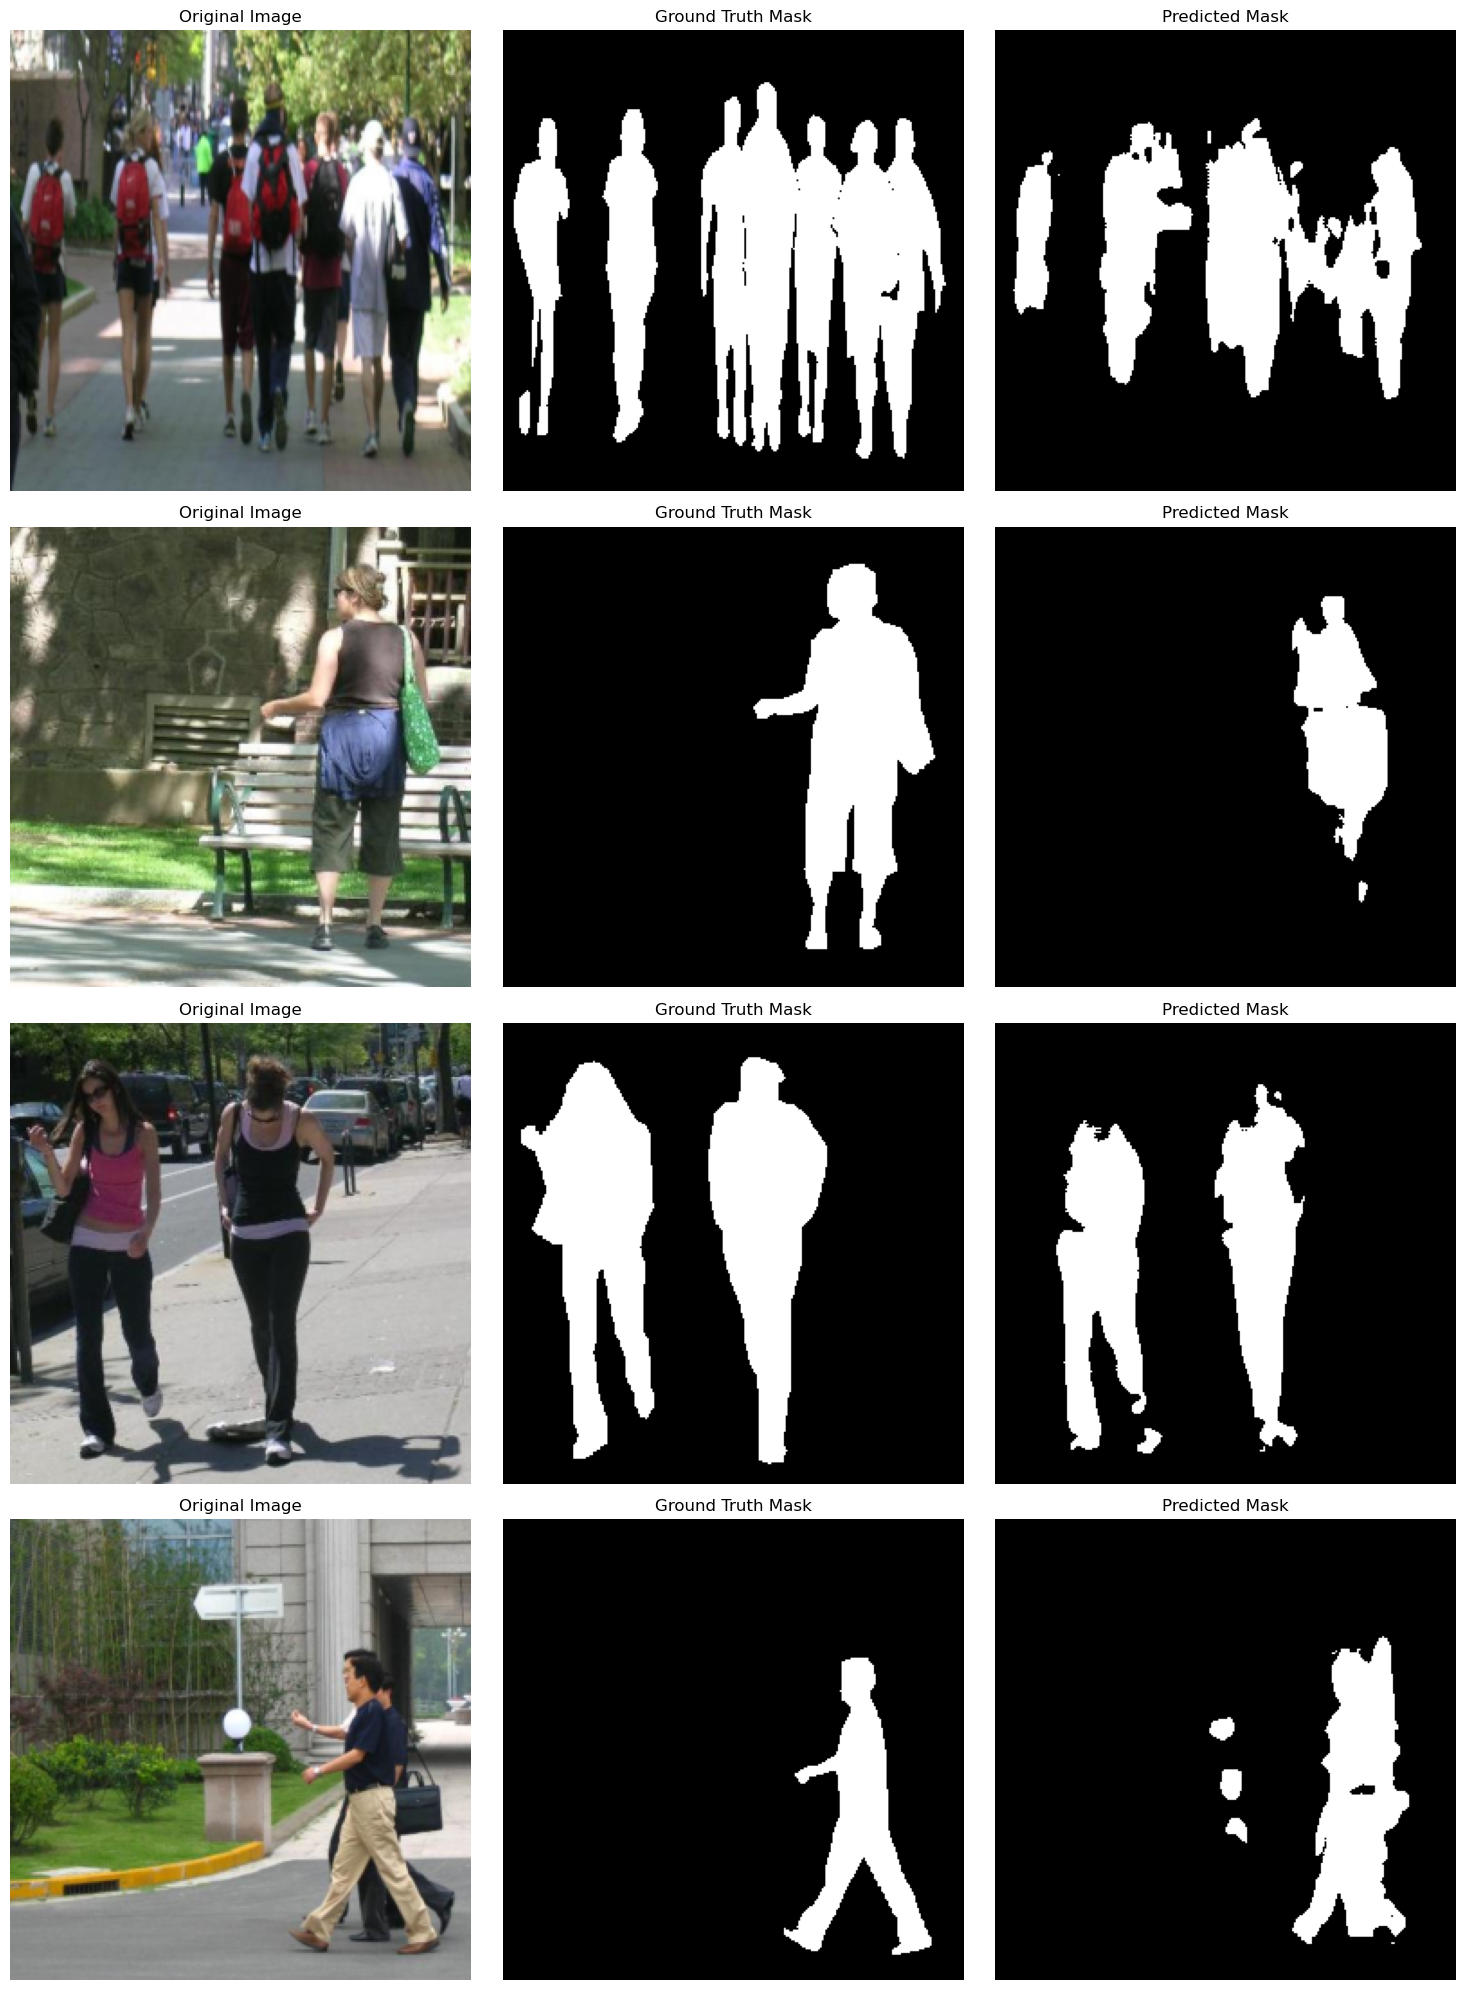

✓ 预测完成！
预测结果可视化完成！


In [9]:
print("进行预测和可视化...")
try:
    model.eval()
    imgs, true_masks = next(iter(test_loader))
    imgs_device = imgs.to(device)
    true_masks_device = true_masks.to(device)

    with torch.no_grad():
        pred_masks = model(imgs_device)
        pred_masks = torch.sigmoid(pred_masks)
        pred_masks = (pred_masks > 0.5).float()

    # 反归一化用的参数
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    # 显示前 4 张或更少
    num_samples = min(4, len(imgs))
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(num_samples):
        # 原始图像 - 反归一化
        img_cpu = imgs[i].cpu()
        img_denorm = (img_cpu * std + mean).clamp(0, 1)
        img_np = img_denorm.permute(1, 2, 0).numpy()
        
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title("Original Image")
        axes[i, 0].axis('off')
        
        # 真实标签
        true_mask_np = true_masks[i].squeeze().numpy()
        axes[i, 1].imshow(true_mask_np, cmap='gray')
        axes[i, 1].set_title("Ground Truth Mask")
        axes[i, 1].axis('off')
        
        # 预测结果
        pred_mask_np = pred_masks[i].cpu().squeeze().numpy()
        axes[i, 2].imshow(pred_mask_np, cmap='gray')
        axes[i, 2].set_title("Predicted Mask")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()
    print("✓ 预测完成！")
    
except Exception as e:
    print(f"预测出错: {str(e)}")
    import traceback
    traceback.print_exc()
print("预测结果可视化完成！")

## 7. 总结

本实验完成了基于 U-Net 的行人图像分割任务，主要内容包括：

1.  **数据准备**：使用了包含 170 张图像的 **Penn-Fudan Pedestrian Dataset**，并将多实例掩膜转换为二分类掩膜（背景 vs 行人）。
2.  **模型构建**：从零实现了经典的 **U-Net** 网络架构，包含 4 层下采样和 4 层上采样。
3.  **训练过程**：使用 **RMSprop** 优化器和 **BCEWithLogitsLoss** 损失函数进行了 10 个 Epoch 的训练。
4.  **结果可视化**：绘制了训练/验证 Loss 曲线，并直观展示了模型对测试集图片的分割预测结果。

### 模型特点

*   **典型的 Encoder-Decoder 架构**：左侧收缩路径提取特征，右侧扩张路径恢复分辨率。
*   **跳跃连接 (Skip Connections)**：解决了深层网络在恢复分辨率时丢失细节的问题，对边缘分割效果显著。
*   **端到端像素级预测**：输入图像，直接输出同尺寸的分割掩膜。
*   **输入图像大小**：本实验统一处理为 256x256。